Trabajamos con **10,000 reseñas reales de Amazon escritas en español**, cada una con su puntuación de 1 a 5 estrellas, para **clasificar si una reseña es positiva o negativa**.

| Parte | Qué hacemos | Ejercicios |
|-------|-------------|------------|
| 0. Los datos | Explorar las reseñas y preparar la tarea de clasificación | 1 y 2 |
| 1. NLP clásico | Preprocesado en español, n-gramas, TF-IDF, Naive Bayes, regresión logística, experimentos, interpretación y análisis de errores | 3 a 10 |
| 2. Similitud y redes neuronales | Buscador por similitud coseno, red neuronal en PyTorch y sus embeddings | 11 a 13 |
| 3. Cierre | Comparación de modelos, reto multiclase y conclusiones | 14 a 16 |

Cada ejercicio tiene la estructura **enunciado → solución → respuesta**. Las soluciones no son las únicas posibles: si llegaste al mismo resultado por otro camino, también es válido. Ejecuta las celdas **en orden**.

## Preparación

Importamos las librerías y fijamos la semilla para que los resultados sean reproducibles. Son las mismas del tutorial: NumPy, pandas, matplotlib, scikit-learn y PyTorch.

In [1]:
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pd.set_option("display.max_colwidth", 150)

print("Listo. Versiones:", f"pandas {pd.__version__}", f"torch {torch.__version__}", sep="\n  ")

Listo. Versiones:
  pandas 3.0.5
  torch 2.14.0


---
# Parte 0. Los datos: reseñas de Amazon en español

Usaremos una parte del **Multilingual Amazon Reviews Corpus** (MARC), un dataset público de reseñas de productos. Cada fila tiene:

- `titulo`: el título que el cliente escribió para su reseña.
- `texto`: el cuerpo de la reseña.
- `estrellas`: la puntuación, de 1 (muy mala) a 5 (excelente).

El archivo debe estar en `data/resenas_amazon_es.csv`. Si no lo tienes, la celda siguiente lo **descarga automáticamente** (unos 2 MB) desde Hugging Face y lo guarda en esa carpeta. Celda ya resuelta.

In [2]:
DATA_PATH = Path("../data/resenas_amazon_es.csv")

if not DATA_PATH.exists():
    print("Descargando el dataset...")
    url = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/{}.jsonl"
    crudo = pd.concat([pd.read_json(url.format(parte), lines=True) for parte in ["test", "validation"]],
                      ignore_index=True)
    titulo_y_texto = crudo["text"].str.split("\n\n", n=1, expand=True)   # el título va en la primera línea
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({
        "titulo": titulo_y_texto[0].str.strip(),
        "texto": titulo_y_texto[1].str.strip().str.replace(r"\s+", " ", regex=True),
        "estrellas": crudo["label"] + 1,                                  # etiquetas 0-4 → 1-5 estrellas
    }).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
df.head()

Descargando el dataset...


,titulo,texto,estrellas
0,no me llego,no me llego el articulo me lo mando por correos normal sin seguimiento y nunca me llego tota un desastre,1
1,amazon sigue sin cumplir en las entregas,"la mensajería horrible, no compro mas",1
2,ESTAFA EN EL ENVÍO,Estoy muy decepcionado con el vendedor ya que el pedido no me llegó a tiempo y no cumplió los plazos de envío y era una cosa que necesitaba urgent...,1
3,Estafa de Amazon,Mi valoración no es sobre el producto sino sobre AMAZON. Ofrecéis el producto a 299€ y tras varios días me devolvéis el dinero porque os habéis eq...,1
4,No conseguí pasar de la portada en Kindle,Pues tenía interés en este libro y probé la versión kindle. se abre la portada pero nada más. parece una mala broma pero me iba a gastar el dedo d...,1


## Ejercicio 1. Conoce el dataset

Calcula:

a) `n_resenas`: el número total de reseñas.

b) `conteo_estrellas`: cuántas reseñas hay de cada puntuación, como una Serie **ordenada de 1 a 5 estrellas** (pista: `value_counts().sort_index()`).

c) `n_duplicados`: cuántas reseñas tienen el **`texto` repetido** (pista: `df.duplicated(subset=...)`).

d) `mediana_palabras`: la **mediana del número de palabras** del `texto` para cada número de estrellas. Pista: `df["texto"].str.split().str.len()` da el número de palabras de cada reseña; luego agrupa por `df["estrellas"]`.

**Solución**

In [3]:
n_resenas = len(df)
conteo_estrellas = df["estrellas"].value_counts().sort_index()
n_duplicados = df.duplicated(subset=["texto"]).sum()
mediana_palabras = df["texto"].str.split().str.len().groupby(df["estrellas"]).median()

print(f"Reseñas: {n_resenas} | duplicadas: {n_duplicados}")
print("\nReseñas por estrellas:\n", conteo_estrellas)
print("\nMediana de palabras por estrellas:\n", mediana_palabras)

Reseñas: 10000 | duplicadas: 20

Reseñas por estrellas:
 estrellas
1    2000
2    2000
3    2000
4    2000
5    2000
Name: count, dtype: int64

Mediana de palabras por estrellas:
 estrellas
1    22.0
2    24.0
3    23.0
4    21.0
5    20.0
Name: texto, dtype: float64


Celda ya resuelta: leamos una reseña de cada puntuación.

In [4]:
for estrellas in range(1, 6):
    ejemplo = df[df["estrellas"] == estrellas].sample(1, random_state=SEED).iloc[0]
    print(f"{'*' * estrellas:<5} | {ejemplo['titulo']}\n        {ejemplo['texto']}\n")

*     | No vale
        El cristal que me a llegado no es para un iphone X

**    | Calidad de acabado
        No es muy estable,la calidad es buena Pero falla mucho , incluso con la última actualización del software

***   | Adolfo montero
        Hola buenas tardes. Me ha llegado la cámara pero necesitaría, si me podéis enviar, las instrucciones en español. Gracias y un saludo

****  | Calidad precio
        Estéticamente queda muy Bonita en mi Sony a6300 y el agarre es muy cómodo la pega es que se desenrosca muchísimo ay que estar apretando cada vez que cojo la camara

***** | El acabado y la calidad
        Me gusta todo. No tiene ninguna falla



**Para analizar**

1. ¿Las clases están balanceadas? Compáralo con el dataset de spam del tutorial. ¿Qué exactitud tendría aquí un modelo que responda siempre lo mismo?
2. ¿Qué reseñas son más largas, las negativas o las positivas? ¿Por qué crees que pasa?
3. Lee los ejemplos. ¿Qué puntuación crees que será la más difícil de clasificar como "positiva" o "negativa"?

**Respuesta:** 1. Sí, están perfectamente balanceadas: 2,000 reseñas de cada puntuación. En el spam solo ~13% era spam y un modelo "tonto" llegaba a ~87% de exactitud. Aquí, en la tarea binaria (positiva frente a negativa), un modelo que responda siempre lo mismo acertaría solo el **50%**, así que la exactitud sí será una métrica informativa.
2. Las negativas son algo más largas: mediana de 22 y 24 palabras con 1 y 2 estrellas, frente a 21 y 20 con 4 y 5. La diferencia es pequeña, pero tiene sentido: cuando algo sale mal, el cliente explica qué pasó (el envío, el defecto, la devolución); cuando sale bien, suele bastar con "muy bueno, lo recomiendo". Las de 2 estrellas son las más largas porque suelen matizar ("está bien, pero...").

Sobre los 20 duplicados: son textos cortos y genéricos ("Perfecto", "Muy bien") que escribieron clientes distintos. En el ejercicio 2 buscaremos duplicados en título + texto, y ahí casi todos dejan de serlo.
3. Las de **3 estrellas**: son neutras o mezclan cosas buenas y malas ("cumple, pero la calidad es regular"). Por eso en el ejercicio 2 las dejaremos fuera del entrenamiento, y en el ejercicio 10 veremos qué opina el modelo de ellas.

In [7]:
df[df.duplicated(subset=["texto"])].sort_values(by="texto")

,titulo,texto,estrellas
3897,Buena calidad precio,Buena calidad precio,4
7763,Correcto sin mas,Buena relación calidad precio,3
8752,Recomendable,Buena relación calidad precio,4
8188,Buena calidad,Buena relación calidad precio,4
8179,Cómodos,Buena relación calidad precio,4
8011,La iluminación,Buena relación calidad precio,4
8597,Calidad,Buena relación calidad-precio,4
8070,Perfecto para principiantes,Buena relación calidad-precio,4
8582,Una alfombra,Cumple las espectativas,4
4790,Cómodo de uso,Cumple las expectativas,5


## Ejercicio 2. Prepara la tarea de clasificación

Vamos a convertir el problema en una **clasificación binaria**, como el spam:

a) Crea en `df` la columna `resena`, que une título y texto: `titulo + ". " + texto`. El título suele ser un resumen muy útil ("Muy mala calidad").

b) Elimina las filas con `resena` duplicada y guarda el resultado en el mismo `df` (con `reset_index(drop=True)`).

c) Crea `df_bin`: una copia de `df` **sin las reseñas de 3 estrellas**, con una columna `positiva` que valga `1` si tiene 4 o 5 estrellas y `0` si tiene 1 o 2.

d) Separa `df_bin` en `train` (80%) y `test` (20%) con `train_test_split`, usando `stratify=df_bin["positiva"]` y `random_state=SEED`. Separamos el DataFrame completo (no solo el texto) porque más adelante necesitaremos las estrellas de cada reseña.

**Solución**

In [8]:
df["resena"] = df["titulo"] + ". " + df["texto"]
df = df.drop_duplicates(subset=["resena"]).reset_index(drop=True)

df_bin = df[df["estrellas"] != 3].copy()
df_bin["positiva"] = (df_bin["estrellas"] >= 4).astype(int)

train, test = train_test_split(df_bin, test_size=0.2, stratify=df_bin["positiva"], random_state=SEED)

Celda ya resuelta: definimos los nombres que usaremos en el resto de la práctica.

In [9]:
X_train, y_train = train["resena"], train["positiva"]
X_test, y_test = test["resena"], test["positiva"]

print(f"Reseñas sin duplicados: {len(df)} | sin las de 3 estrellas: {len(df_bin)}")
print(f"Entrenamiento: {len(train)} | Prueba: {len(test)} | % positivas en prueba: {100 * y_test.mean():.1f}%")

Reseñas sin duplicados: 9998 | sin las de 3 estrellas: 7998
Entrenamiento: 6398 | Prueba: 1600 | % positivas en prueba: 50.0%


---
# Parte 1. NLP clásico

## Ejercicio 3. Preprocesado para el español

El español tiene detalles que el inglés no: **tildes** ("está" y "esta"), la **ñ** y clientes que escriben con y sin tildes ("rápido" y "rapido"). Para que "envío" y "envio" sean el mismo token, normalizaremos el texto.

La lista `STOPWORDS_ES` (ya resuelta, basada en la de NLTK y escrita **sin tildes**) contiene las palabras vacías más comunes. Fíjate en que incluye negaciones como "no", "nada" o "sin", que guardamos aparte en `NEGACIONES`.

In [10]:
STOPWORDS_ES = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para", "con",
    "no", "una", "su", "al", "lo", "como", "mas", "pero", "sus", "le", "ya", "o", "este", "si",
    "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "tambien", "me", "hasta", "hay",
    "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni", "contra",
    "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mi", "antes", "algunos", "que", "unos",
    "yo", "otro", "otras", "otra", "el", "tanto", "esa", "estos", "mucho", "quienes", "nada",
    "muchos", "cual", "poco", "ella", "estar", "estas", "algunas", "algo", "nosotros", "mis",
    "tu", "te", "ti", "tus", "es", "son", "fue", "ha", "he", "han", "ser", "tiene", "tengo",
    "era", "sea", "nunca", "tampoco", "asi", "aunque", "solo", "bien", "va", "hace",
}
NEGACIONES = {"no", "ni", "nada", "nunca", "sin", "tampoco"}

print(f"{len(STOPWORDS_ES)} stopwords | negaciones incluidas: {sorted(NEGACIONES & STOPWORDS_ES)}")

105 stopwords | negaciones incluidas: ['nada', 'ni', 'no', 'nunca', 'sin', 'tampoco']


Programa:

a) `normalizar(texto)`: pasa el texto a minúsculas y quita las tildes de las vocales (á→a, é→e, í→i, ó→o, ú→u, ü→u), **conservando la ñ**. Pista: `str.maketrans("áéíóúü", "aeiouu")` crea una tabla de reemplazos que se aplica con `texto.translate(tabla)`.

b) `tokenizar(texto)`: normaliza el texto y devuelve la lista de tokens formados por letras (incluida la ñ) o números. Pista: `re.findall(r"[a-zñ0-9]+", ...)`.

c) `limpiar(texto)`: tokeniza y elimina las stopwords de `STOPWORDS_ES` y los tokens de un solo carácter.

d) Con `limpiar()`, obtén las **15 palabras más frecuentes** de las reseñas positivas y de las negativas del set de **entrenamiento** (`train`): `top_positivas` y `top_negativas` (pista: `Counter(...).most_common(15)`).

e) `pct_con_no`: un diccionario con el **porcentaje de reseñas** de cada clase (`"positivas"` y `"negativas"`) que contienen el token `"no"`. Usa `tokenizar()`, no `limpiar()`.

**Solución**

In [11]:
TILDES = str.maketrans("áéíóúü", "aeiouu")


def normalizar(texto):
    return texto.lower().translate(TILDES)


def tokenizar(texto):
    return re.findall(r"[a-zñ0-9]+", normalizar(texto))


def limpiar(texto):
    return [t for t in tokenizar(texto) if t not in STOPWORDS_ES and len(t) > 1]


positivas = train.loc[train["positiva"] == 1, "resena"]
negativas = train.loc[train["positiva"] == 0, "resena"]

top_positivas = Counter(t for r in positivas for t in limpiar(r)).most_common(15)
top_negativas = Counter(t for r in negativas for t in limpiar(r)).most_common(15)

pct_con_no = {
    "positivas": round(100 * float(np.mean(["no" in tokenizar(r) for r in positivas])), 1),
    "negativas": round(100 * float(np.mean(["no" in tokenizar(r) for r in negativas])), 1),
}

ejemplo = "¡Llegó RÁPIDO y la añadí a mi colección! Pero el envío no traía la batería..."
print("normalizar:", normalizar(ejemplo))
print("tokenizar: ", tokenizar(ejemplo))
print("limpiar:   ", limpiar(ejemplo))
print("\nPositivas:", top_positivas)
print("Negativas:", top_negativas)
print("\n% de reseñas con 'no':", pct_con_no)

normalizar: ¡llego rapido y la añadi a mi coleccion! pero el envio no traia la bateria...
tokenizar:  ['llego', 'rapido', 'y', 'la', 'añadi', 'a', 'mi', 'coleccion', 'pero', 'el', 'envio', 'no', 'traia', 'la', 'bateria']
limpiar:    ['llego', 'rapido', 'añadi', 'coleccion', 'envio', 'traia', 'bateria']

Positivas: [('calidad', 953), ('buena', 816), ('precio', 792), ('buen', 632), ('producto', 530), ('perfecto', 427), ('compra', 288), ('bastante', 280), ('facil', 275), ('cumple', 247), ('bueno', 222), ('genial', 206), ('relacion', 201), ('perfectamente', 198), ('funciona', 195)]
Negativas: [('calidad', 629), ('producto', 610), ('mal', 316), ('mala', 312), ('dos', 282), ('llego', 270), ('recomiendo', 259), ('funciona', 252), ('precio', 228), ('llegado', 216), ('parece', 199), ('compre', 193), ('amazon', 185), ('uso', 177), ('comprar', 175)]

% de reseñas con 'no': {'positivas': 29.3, 'negativas': 74.1}


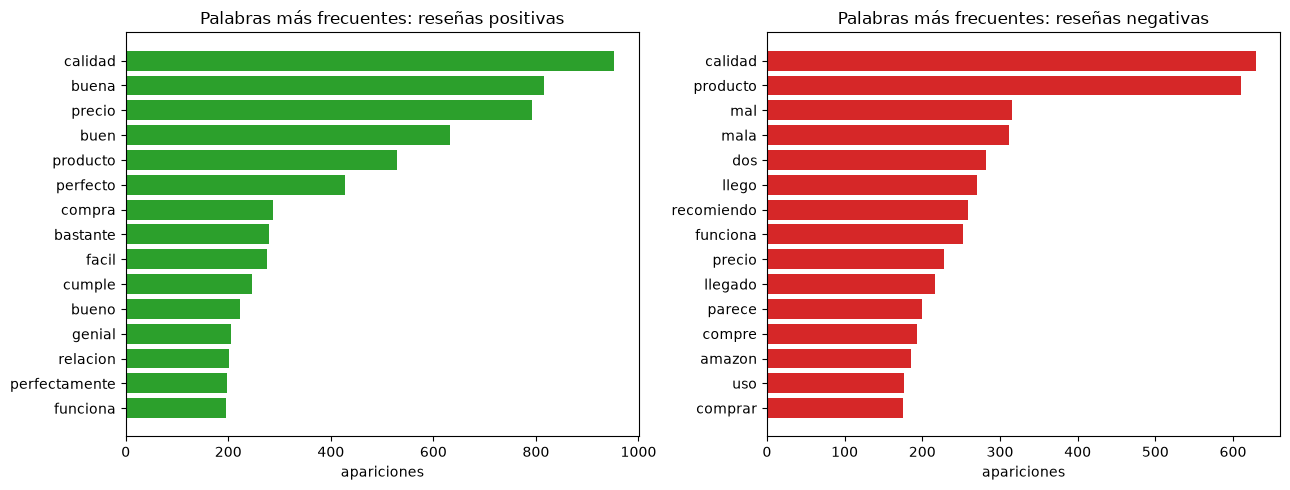

In [12]:
# Visualización (ya resuelta): palabras más frecuentes por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (titulo, top, color) in zip(axes, [("Positivas", top_positivas, "tab:green"),
                                           ("Negativas", top_negativas, "tab:red")]):
    palabras, conteos = zip(*top)
    ax.barh(palabras[::-1], conteos[::-1], color=color)
    ax.set_title(f"Palabras más frecuentes: reseñas {titulo.lower()}")
    ax.set_xlabel("apariciones")
plt.tight_layout()
plt.show()

**Para analizar**

1. ¿Qué palabras aparecen **en ambas** listas? ¿Sirven para distinguir una reseña positiva de una negativa?
2. Según el punto e), ¿es buena idea eliminar "no" como stopword en esta tarea? ¿Qué le pasaría a la reseña "no funciona" después de `limpiar()`?

**Respuesta:** 1. "calidad", "producto", "precio" y "funciona" aparecen en las dos listas: indican de **qué** habla la reseña (el tema), no **qué opina** el cliente. "calidad" puede venir de "buena calidad" o de "mala calidad", y "funciona" de "funciona perfectamente" o de "no funciona". Las palabras que sí distinguen son las que solo están en una lista: "perfecto", "genial", "facil" o "cumple" frente a "mal", "mala" o "llegado" (de "no ha llegado"). Curioso: "recomiendo" está entre las más frecuentes de las **negativas**, porque viene de "no lo recomiendo" y la limpieza borró el "no".
2. No es buena idea: "no" aparece en el 74% de las reseñas negativas y solo en el 29% de las positivas, así que **por sí sola** ya es una pista muy fuerte. Además, `limpiar("no funciona")` devuelve `["funciona"]`: una queja queda convertida en algo que suena positivo, como pasó con "recomiendo". Lo comprobaremos con números en el ejercicio 7.

## Ejercicio 4. Bigramas: el contexto inmediato

Programa `top_ngramas(textos, ngram_range=(2, 2), stop_words=None, n=10)`, que devuelve una Serie con los `n` n-gramas más frecuentes de `textos` y su número de apariciones, ordenada de mayor a menor. Usa `CountVectorizer(ngram_range=..., stop_words=..., strip_accents="unicode")`.

Pista: es lo mismo que el ejercicio 5 d) del tutorial, pero empaquetado en una función.

Luego calcula los **bigramas más frecuentes** de las reseñas positivas y negativas de `train` en dos versiones:

a) `bigramas_pos_todas` y `bigramas_neg_todas`: sin quitar stopwords.

b) `bigramas_pos` y `bigramas_neg`: quitando las stopwords **excepto las negaciones** (`sorted(STOPWORDS_ES - NEGACIONES)`).

**Solución**

In [13]:
def top_ngramas(textos, ngram_range=(2, 2), stop_words=None, n=10):
    vectorizador = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words, strip_accents="unicode")
    conteos = vectorizador.fit_transform(textos)
    frecuencias = pd.Series(np.asarray(conteos.sum(axis=0)).ravel(), index=vectorizador.get_feature_names_out())
    return frecuencias.sort_values(ascending=False).head(n)


positivas = train.loc[train["positiva"] == 1, "resena"]
negativas = train.loc[train["positiva"] == 0, "resena"]

bigramas_pos_todas = top_ngramas(positivas)
bigramas_neg_todas = top_ngramas(negativas)

STOP_SIN_NEGACIONES = sorted(STOPWORDS_ES - NEGACIONES)
bigramas_pos = top_ngramas(positivas, stop_words=STOP_SIN_NEGACIONES)
bigramas_neg = top_ngramas(negativas, stop_words=STOP_SIN_NEGACIONES)

# Tabla resumen: cada celda muestra "bigrama (apariciones)"
pd.DataFrame({nombre: [f"{t} ({c})" for t, c in serie.items()]
              for nombre, serie in [("positivas (todas)", bigramas_pos_todas), ("negativas (todas)", bigramas_neg_todas),
                                    ("positivas", bigramas_pos), ("negativas", bigramas_neg)]})

,positivas (todas),negativas (todas),positivas,negativas
0,muy bien (511),no me (453),calidad precio (380),no recomiendo (238)
1,lo que (404),no se (415),buena calidad (284),mala calidad (181)
2,calidad precio (366),no lo (373),buen producto (203),no funciona (180)
3,buena calidad (284),no es (368),relacion calidad (184),no llegado (103)
4,en la (279),lo que (342),buena compra (124),producto no (91)
5,un poco (250),de la (334),buen precio (106),no recibido (85)
6,es muy (249),que no (302),buena relacion (99),no sirve (84)
7,de la (243),el producto (285),cumple funcion (69),no gustado (78)
8,en el (217),me ha (279),precio buena (43),no puedo (67)
9,no se (207),en la (271),precio calidad (43),no vale (67)


**Para analizar**

1. En la versión a), ¿qué tipo de bigramas dominan? ¿Cuáles de ellos sí aportan información sobre el sentimiento?
2. En la versión b), busca bigramas con "no". ¿Qué información capturan que las palabras sueltas no pueden capturar?

**Respuesta:** 1. Hay muchas combinaciones de palabras vacías ("lo que", "de la", "en la") que aparecen en cualquier texto en español. Aun así, ya se nota el sentimiento: en las positivas, "muy bien", "calidad precio" y "buena calidad"; en las negativas, **casi todo el top empieza por "no"** ("no me", "no se", "no lo", "no es"). La negación es la marca más clara de una reseña negativa.
2. Aparecen "no recomiendo", "no funciona", "no llegado", "no sirve" o "no gustado": la negación **cambia el significado** de la palabra que la sigue. "recomiendo" suelto es positivo, pero "no recomiendo" es claramente negativo, y este bigrama resuelve la confusión que vimos en el ejercicio 3. Una bolsa de unigramas no puede distinguirlos; los bigramas recuperan un poco del orden. Ojo: al quitar stopwords se forman bigramas "artificiales" (de "no lo recomiendo" sale "no recomiendo"), pero aquí eso nos favorece.

## Ejercicio 5. TF-IDF para extraer palabras clave

TF-IDF no solo sirve para clasificar: también indica qué palabras son **características** de un documento. Las palabras que aparecen en casi todas las reseñas tienen un IDF bajo; las raras, uno alto.

a) Crea `vectorizador_kw`: un `TfidfVectorizer(strip_accents="unicode", stop_words=sorted(STOPWORDS_ES))` ajustado (`.fit`) con `X_train`.

b) Con el atributo `vectorizador_kw.idf_` (un IDF por término, en el mismo orden que `get_feature_names_out()`), crea la Serie `idf` indexada por término y muestra los **10 términos con menor IDF** (los más comunes).

c) Programa `palabras_clave(texto, n=5)`: transforma el texto con `vectorizador_kw` y devuelve los `n` términos con **mayor peso TF-IDF** en ese texto (solo los que tengan peso mayor que 0).

**Solución**

In [14]:
vectorizador_kw = TfidfVectorizer(strip_accents="unicode", stop_words=sorted(STOPWORDS_ES)).fit(X_train)

idf = pd.Series(vectorizador_kw.idf_, index=vectorizador_kw.get_feature_names_out())
print("Términos con menor IDF (los más comunes):\n", idf.sort_values().head(10).round(2))


def palabras_clave(texto, n=5):
    pesos = vectorizador_kw.transform([texto]).toarray()[0]
    terminos = vectorizador_kw.get_feature_names_out()
    orden = np.argsort(pesos)[::-1][:n]
    return [terminos[i] for i in orden if pesos[i] > 0]


for resena in test["resena"].iloc[:4]:
    print(f"\n{resena}\n  → {palabras_clave(resena)}")

Términos con menor IDF (los más comunes):
 calidad       2.62
producto      2.95
precio        3.00
buena         3.09
buen          3.41
recomiendo    3.74
llego         3.76
perfecto      3.76
compra        3.81
bastante      3.81
dtype: float64

Perfectas. Una buena forma de ahorrar espacio.
  → ['ahorrar', 'perfectas', 'espacio', 'forma', 'buena']

Poca fuerza. Tiene muy poquita fuerza para sacar los corchos aún cargando la batería al completo.
  → ['fuerza', 'cargando', 'sacar', 'completo', 'poca']

Cumple su función. En un bidón más pesado que los normales, si miras cada gramo, éste no es tu bidón. Cumple su función. La válvula funciona bien. A veces pierde agua al beber, no sé si es por la rosca del tapón o por la parte baja de la tetina, porque desenrosco y enrosco y sigue pasando.
  → ['bidon', 'pasando', 'gramo', 'funcion', 'tetina']

Perfecta en todo. Somos familia numerosa y ya había tenido otra cortadora de fiambre ya que me resulta mas económico comprar piezas enteras y n

**Para analizar:** ¿por qué "calidad" y "producto" tienen un IDF tan bajo? ¿Las palabras clave que encontraste resumen bien de qué trata cada reseña? ¿Hablan del tema o de la opinión?

**Respuesta:** Porque aparecen en una gran proporción de las reseñas (casi todas hablan de la calidad de un producto), así que no sirven para diferenciarlas, igual que "el" en el ejercicio de TF-IDF del tutorial. En las reseñas cortas, las palabras clave resumen bien **el tema** ("ahorrar espacio"; "fuerza" y "sacar" corchos; "bidon" y "tetina"), porque las palabras específicas son raras y tienen IDF alto. Pero tienen limitaciones: en la reseña larga de la cortadora de fiambre salen "puedo", "verdad" o "somos", palabras poco frecuentes pero sin contenido que nuestra lista de stopwords no incluye. Y casi nunca capturan **la opinión**: las palabras de valoración ("buena", "perfecto", "calidad") son frecuentes y pesan poco. Por eso TF-IDF es útil para buscar y resumir, y para el sentimiento conviene que un clasificador aprenda qué términos importan.

## Ejercicio 6. Línea base: Naive Bayes y regresión logística

Entrena los dos modelos clásicos del tutorial con `make_pipeline`:

- `modelo_nb`: `CountVectorizer(strip_accents="unicode")` + `MultinomialNB()`.
- `modelo_lr`: `TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2))` + `LogisticRegression(max_iter=1000)`.

Para cada uno, entrena con `X_train, y_train`, predice sobre `X_test` (`pred_nb`, `pred_lr`) y mide el tiempo de entrenamiento con `time.time()` (`tiempo_nb`, `tiempo_lr`).

Calcula también `exactitud_tonto`: la exactitud de un "modelo" que predice **siempre 1** (positiva) sobre `y_test`.

**Solución**

In [15]:
modelo_nb = make_pipeline(CountVectorizer(strip_accents="unicode"), MultinomialNB())
modelo_lr = make_pipeline(TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2)),
                          LogisticRegression(max_iter=1000))

inicio = time.time()
modelo_nb.fit(X_train, y_train)
tiempo_nb = time.time() - inicio
pred_nb = modelo_nb.predict(X_test)

inicio = time.time()
modelo_lr.fit(X_train, y_train)
tiempo_lr = time.time() - inicio
pred_lr = modelo_lr.predict(X_test)

exactitud_tonto = accuracy_score(y_test, np.ones(len(y_test)))

Celda ya resuelta: resumen de métricas y matrices de confusión. Recuerda que aquí la clase "positiva" (1) es la reseña positiva, así que la precisión responde a "de las que el modelo dijo positivas, ¿cuántas lo eran?".

,exactitud,precisión,recall,F1
Siempre positiva,0.500,NaN,NaN,NaN
Naive Bayes,0.879,0.859,0.906,0.882
TF-IDF + Reg. logística,0.902,0.905,0.898,0.901


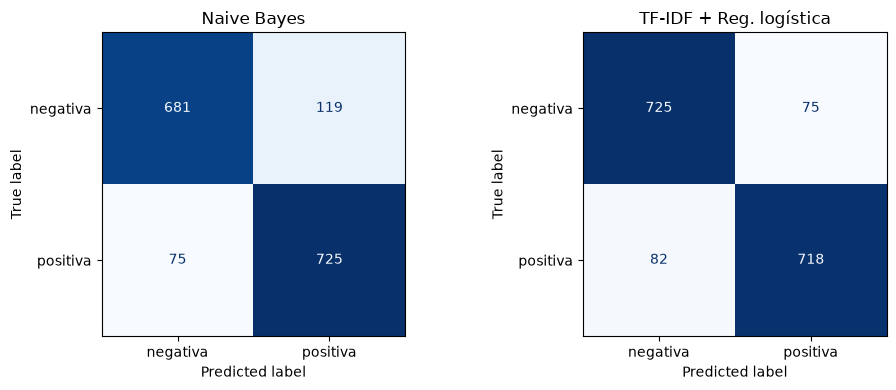

In [16]:
def resumen_metricas(y_real, y_pred):
    return {"exactitud": accuracy_score(y_real, y_pred), "precisión": precision_score(y_real, y_pred),
            "recall": recall_score(y_real, y_pred), "F1": f1_score(y_real, y_pred)}


resultados = pd.DataFrame({
    "Siempre positiva": {"exactitud": exactitud_tonto},
    "Naive Bayes": resumen_metricas(y_test, pred_nb),
    "TF-IDF + Reg. logística": resumen_metricas(y_test, pred_lr),
}).T
display(resultados.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nombre, pred) in zip(axes, [("Naive Bayes", pred_nb), ("TF-IDF + Reg. logística", pred_lr)]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["negativa", "positiva"],
                                            ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

**Para analizar**

1. Compara la exactitud del modelo "siempre positiva" con la del tutorial de spam. ¿Por qué ahora es tan baja?
2. ¿Los modelos funcionan tan bien como en el spam? ¿Por qué crees que el sentimiento es una tarea más difícil?
3. Según las matrices de confusión, ¿los errores están equilibrados entre ambas clases?

**Respuesta:** 1. Porque las clases están balanceadas: acertar siempre "positiva" da un 50%, que es lo mismo que lanzar una moneda. En el spam, el 87% de los mensajes eran ham y el modelo tonto parecía bueno.
2. Funcionan bien (88% de exactitud con Naive Bayes y 90% con la regresión logística), pero peor que en el spam, donde Naive Bayes llegaba a un F1 ≈ 0.92. En el spam bastan palabras muy delatoras ("free", "prize", "claim"). En el sentimiento, la misma palabra puede ir en ambos sentidos ("calidad", "precio", "funciona"), y el significado depende de negaciones, contrastes ("bonito, pero se rompió") e ironía, que una bolsa de palabras capta solo en parte.
3. En la regresión logística, sí: comete un número parecido de falsos positivos y falsos negativos, y por eso su precisión y su recall son casi iguales (~0.90). Naive Bayes, en cambio, tiende a decir "positiva" de más: tiene más recall (0.91) que precisión (0.86), es decir, más reseñas negativas clasificadas como positivas que al revés.

## Ejercicio 7. Experimentos de preprocesado

En el tutorial vimos que las decisiones de preprocesado dependen de la tarea. Ahora lo vas a **medir**. La celda siguiente (ya resuelta) define cinco configuraciones de `TfidfVectorizer`.

In [17]:
CONFIGURACIONES = {
    "A. Unigramas": TfidfVectorizer(strip_accents="unicode"),
    "B. Unigramas sin stopwords": TfidfVectorizer(strip_accents="unicode", stop_words=sorted(STOPWORDS_ES)),
    "C. Unigramas sin stopwords (conserva negaciones)": TfidfVectorizer(strip_accents="unicode",
                                                                        stop_words=STOP_SIN_NEGACIONES),
    "D. Unigramas + bigramas": TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2)),
    "E. Uni + bigramas, min_df=2, sublinear_tf": TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2),
                                                                 min_df=2, sublinear_tf=True),
}

a) Programa `evaluar(vectorizador)`: crea un pipeline con el `vectorizador` y una `LogisticRegression(max_iter=1000)`, entrénalo con `X_train, y_train`, predice sobre `X_test` y devuelve un diccionario con `exactitud`, `F1`, `n_terminos` (el tamaño del vocabulario: `len(vectorizador.vocabulary_)`) y `tiempo (s)` de entrenamiento.

b) Aplica `evaluar()` a cada configuración y guarda los resultados en el DataFrame `resultados_exp`, con una fila por configuración.

`min_df=2` descarta los términos que aparecen en menos de 2 reseñas; `sublinear_tf=True` usa 1 + log(tf) en lugar de tf, para que repetir una palabra muchas veces no pese demasiado.

**Solución**

In [18]:
def evaluar(vectorizador):
    modelo = make_pipeline(vectorizador, LogisticRegression(max_iter=1000))
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - inicio
    pred = modelo.predict(X_test)
    return {"exactitud": accuracy_score(y_test, pred), "F1": f1_score(y_test, pred),
            "n_terminos": len(vectorizador.vocabulary_), "tiempo (s)": tiempo}


resultados_exp = pd.DataFrame({nombre: evaluar(v) for nombre, v in CONFIGURACIONES.items()}).T
resultados_exp.round(3)

,exactitud,F1,n_terminos,tiempo (s)
A. Unigramas,0.901,0.901,12741.0,0.123
B. Unigramas sin stopwords,0.874,0.872,12640.0,0.095
C. Unigramas sin stopwords (conserva negaciones),0.896,0.896,12646.0,0.090
D. Unigramas + bigramas,0.902,0.901,90565.0,0.231
"E. Uni + bigramas, min_df=2, sublinear_tf",0.907,0.906,23438.0,0.193


**Para analizar**

1. Compara A con B. ¿Quitar stopwords ayudó o perjudicó? ¿Y si conservamos las negaciones (C)?
2. ¿Cuánto crece el vocabulario al añadir bigramas (D)? ¿Compensa la mejora?
3. ¿Qué hace `min_df=2` con el número de términos en E? ¿Por qué podría ayudar a generalizar?

**Respuesta:** 1. Quitar todas las stopwords (B) **empeora** el modelo respecto de A: se pierden "no", "nada", "sin" o "muy", que en esta tarea son muy informativas (ejercicio 3). Al conservar las negaciones (C) se recupera gran parte de lo perdido. Conclusión: las listas genéricas de stopwords pueden borrar justo la señal que necesitamos.
2. El vocabulario se multiplica por 7 (de ~12,700 a ~90,600 términos) y, por sí solo, **no mejora** el F1 (0.901 en A y en D). Es el problema de los n-gramas del tutorial: aparecen muchísimos términos nuevos, la mayoría vistos una sola vez, y el modelo no tiene ejemplos suficientes de cada uno.
3. Reduce el vocabulario de ~90,600 a ~23,400 términos: casi tres de cada cuatro bigramas aparecían en una sola reseña. Esos términos no permiten aprender un patrón y aumentan el riesgo de memorizar ruido. Al quitarlos (y con `sublinear_tf`), los bigramas útiles como "no recomiendo" sí aportan, y E consigue el mejor F1 (0.906) con un modelo cuatro veces más pequeño que D.

## Ejercicio 8. ¿Qué aprendió el modelo?

Con `modelo_lr` (el del ejercicio 6), obtén:

- `top_positivos`: los **15 términos** (palabras o bigramas) con **mayor** peso.
- `top_negativos`: los **15 términos** con **menor** peso.

Pista: los términos se obtienen con `modelo_lr.named_steps["tfidfvectorizer"].get_feature_names_out()` y los pesos con `modelo_lr.named_steps["logisticregression"].coef_[0]`. Ordena con `np.argsort`.

**Solución**

In [19]:
terminos = modelo_lr.named_steps["tfidfvectorizer"].get_feature_names_out()
pesos = modelo_lr.named_steps["logisticregression"].coef_[0]

orden = np.argsort(pesos)
top_positivos = list(terminos[orden[::-1][:15]])
top_negativos = list(terminos[orden[:15]])

print("Más positivos:", top_positivos)
print("Más negativos:", top_negativos)

Más positivos: ['buen', 'perfecto', 'buena', 'bien', 'muy', 'muy bien', 'genial', 'precio', 'facil', 'perfectamente', 'excelente', 'cumple', 'perfecta', 'bueno', 'buen producto']
Más negativos: ['no', 'mala', 'mal', 'se', 'no lo', 'mala calidad', 'no me', 'nada', 'no es', 'roto', 'no funciona', 'ni', 'baja', 'demasiado', 'poca']


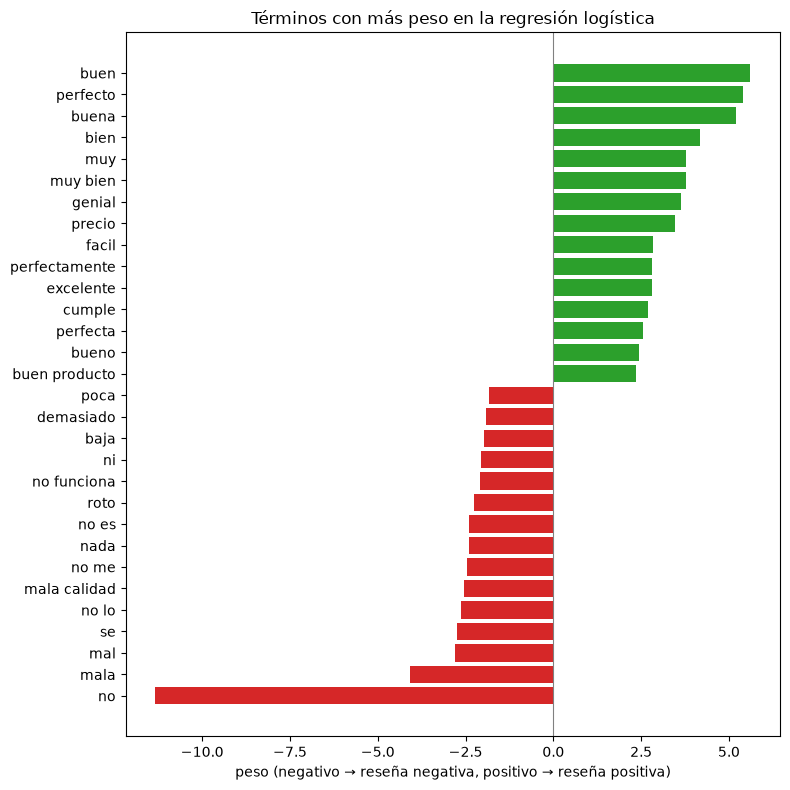

In [20]:
# Visualización (ya resuelta): los pesos más extremos del modelo
orden = np.argsort(pesos)
extremos = np.concatenate([orden[:15], orden[-15:]])
plt.figure(figsize=(8, 8))
plt.barh(terminos[extremos], pesos[extremos],
         color=["tab:red" if p < 0 else "tab:green" for p in pesos[extremos]])
plt.axvline(0, color="gray", lw=0.8)
plt.title("Términos con más peso en la regresión logística")
plt.xlabel("peso (negativo → reseña negativa, positivo → reseña positiva)")
plt.tight_layout()
plt.show()

**Para analizar**

1. ¿Los términos tienen sentido? ¿Aparecen palabras que habríamos eliminado como stopwords?
2. ¿Aparece algún **bigrama** entre los términos con más peso? ¿Qué aporta?

**Respuesta:** 1. Sí: en el lado positivo aparecen "buen", "perfecto", "buena", "genial", "excelente" o "facil"; en el negativo, "mala", "mal", "roto", "baja" o "poca". El término con más peso de todo el modelo es **"no"**, con mucha diferencia (más del doble que cualquier otro). Y varios de los términos más importantes ("no", "muy", "bien", "nada", "ni", "se") estaban en `STOPWORDS_ES`: el modelo confirma que en esta tarea **no** son palabras vacías. "muy" empuja hacia positivo porque los clientes contentos lo usan para intensificar ("muy bien", "muy contento").
2. Sí: "muy bien" y "buen producto" en el lado positivo; "mala calidad", "no funciona", "no lo", "no me" y "no es" en el negativo. Capturan expresiones fijas y negaciones. "funciona" suelto puede ser bueno o malo, pero "no funciona" no deja dudas.

## Ejercicio 9. Ponlo a prueba: frases difíciles y errores

a) Usa `modelo_lr.predict_proba()` para calcular la probabilidad de que cada frase de `FRASES` sea positiva (pista: la columna `1` del resultado). Guarda en `tabla_frases` un DataFrame con las columnas `frase` y `P(positiva)`.

In [21]:
FRASES = [
    "Me encanta, funciona perfecto",
    "No funciona, lo devolví",
    "No está nada mal para el precio",          # negación de algo negativo
    "No me gustó, no lo recomiendo",
    "Genial, se rompió al segundo día",         # ironía
    "Bonito, pero la calidad deja mucho que desear",
    "Llegó a tiempo",                           # neutral
    "Ni bueno ni malo, cumple sin más",
]

**Solución**

In [22]:
tabla_frases = pd.DataFrame({"frase": FRASES, "P(positiva)": modelo_lr.predict_proba(FRASES)[:, 1]})
tabla_frases.round(3)

,frase,P(positiva)
0,"Me encanta, funciona perfecto",0.952
1,"No funciona, lo devolví",0.058
2,No está nada mal para el precio,0.376
3,"No me gustó, no lo recomiendo",0.017
4,"Genial, se rompió al segundo día",0.349
5,"Bonito, pero la calidad deja mucho que desear",0.207
6,Llegó a tiempo,0.624
7,"Ni bueno ni malo, cumple sin más",0.474


b) Ahora analiza los **errores** de `modelo_lr` en el set de prueba. Crea el DataFrame `errores_seguros` con las **8 reseñas mal clasificadas en las que el modelo estaba más seguro**: las que tienen la probabilidad más lejana de 0.5. Incluye las columnas `resena`, `estrellas`, `P(positiva)` y `predicho`.

Pista: crea primero un DataFrame con todas las reseñas de `test`, su probabilidad y su predicción; filtra las filas donde `predicho != positiva` y ordena por `abs(P(positiva) - 0.5)` de mayor a menor.

**Solución**

In [23]:
analisis = test[["resena", "estrellas", "positiva"]].copy()
analisis["P(positiva)"] = modelo_lr.predict_proba(X_test)[:, 1]
analisis["predicho"] = (analisis["P(positiva)"] > 0.5).astype(int)

errores = analisis[analisis["predicho"] != analisis["positiva"]].copy()
errores["seguridad"] = (errores["P(positiva)"] - 0.5).abs()
errores_seguros = (errores.sort_values("seguridad", ascending=False)
                   .head(8)[["resena", "estrellas", "P(positiva)", "predicho"]])
errores_seguros.round(3)

,resena,estrellas,P(positiva),predicho
6681,Bien. Bueno para el precio que tiene,2,0.932,1
8139,Sirve para la v8. Lo he devuelto porque el cepillo no me servía,4,0.109,0
5205,Buena calidad. Esta muy bien la calidad pero lo malo la talla,1,0.888,1
4537,"NO ES DE LA MEDIDA QUE HE SOLICITADO. LO TENGO QUE DEVOLVER. EL PRODUCTO ME ENCANTA, PERO ME HAN MANDADO MEDIDA DIFERENTE A LA QUE PEDI; TENGO QUE...",5,0.121,0
6420,Bien. Es muy mono relación calidad precio buena aunque las calidades no son maravillosas,2,0.876,1
1733,"Buena calidad, falla la talla. Tallaje un poco grande, compré una L que es mi talla y me sobra de cintura. Por lo demás perfecto, material de muy ...",2,0.855,1
9326,"Amazon de diez. A mi no me sirvió, pero el servicio de Amazon brutal, me dejaron devolverlo incluso fuera de plazo (por causa exclusivamente de mi...",5,0.154,0
5773,relacion calidad precio. el producto esta muy bien. en relación calidad precio. llegaría rapido si no fuera por el servicio de mensajeria. es una ...,1,0.831,1


**Para analizar**

1. ¿En qué frases de `FRASES` se equivoca o duda el modelo? Relaciónalo con la ironía, la doble negación y los contrastes con "pero".
2. Lee los errores "seguros". ¿Las etiquetas son siempre correctas? ¿Qué patrones encuentras?

**Respuesta:** 1. Las frases directas las acierta con mucha seguridad (0.95 para "Me encanta...", 0.02 para "No me gustó, no lo recomiendo"). Con las difíciles:
   - "No está nada mal para el precio" (0.38): **falla**. La bolsa de palabras ve "no", "nada" y "mal", tres señales negativas ("no" es el término con más peso de todo el modelo), y no entiende que la doble negación las anula. El bigrama "nada mal" existe en el vocabulario, pero aparece tan poco que su peso es casi nulo.
   - "Genial, se rompió al segundo día" (0.35): acierta, pero con poca seguridad, y no porque entienda la ironía: "se" y "rompió" pesan algo más que "genial". Con otra palabra positiva más, fallaría.
   - "Bonito, pero la calidad deja mucho que desear" (0.21): acierta. Ninguna palabra es negativa por sí sola, pero el modelo aprendió que "deja", "desear" y "que desear" aparecen sobre todo en quejas (por la expresión "deja mucho que desear").
   - "Llegó a tiempo" (0.62) y "Ni bueno ni malo, cumple sin más" (0.47): son neutrales y quedan cerca de 0.5, porque no pertenecen a ninguna de las dos clases con las que entrenamos.
2. No siempre: "Bien. Bueno para el precio que tiene" tiene 2 estrellas y "Sirve para la v8. Lo he devuelto porque el cepillo no me servía" tiene 4. El texto dice una cosa y la puntuación otra: es **ruido en las etiquetas** y ningún modelo puede acertarlo. Otro patrón frecuente son las reseñas **mixtas**, donde el cliente puntúa algo distinto de lo que más describe: "Buena calidad... pero lo malo la talla" (1 estrella), "Amazon de diez. A mí no me sirvió, pero el servicio de Amazon brutal" (5 estrellas), o el producto que "me encanta" pero llegó en otra medida. El modelo suma palabras sin entender cuál es la conclusión del cliente.

## Ejercicio 10. ¿Y las reseñas de 3 estrellas?

El modelo **nunca vio** reseñas de 3 estrellas. ¿Qué opina de ellas? Usaremos la probabilidad `P(positiva)` como un "termómetro" de sentimiento.

a) Calcula `prob_3`: la probabilidad de ser positiva, según `modelo_lr`, de **todas** las reseñas de 3 estrellas de `df`.

b) Crea `prob_por_estrellas`: un diccionario `{estrellas: arreglo de probabilidades}` con las probabilidades de las reseñas de **prueba** de 1, 2, 4 y 5 estrellas, más las de 3 estrellas del punto a).

c) Crea `media_por_estrellas`: una Serie con la **probabilidad media** de cada número de estrellas (1 a 5).

**Solución**

In [24]:
prob_3 = modelo_lr.predict_proba(df.loc[df["estrellas"] == 3, "resena"])[:, 1]

prob_test = modelo_lr.predict_proba(X_test)[:, 1]
prob_por_estrellas = {e: prob_test[test["estrellas"].values == e] for e in [1, 2, 4, 5]}
prob_por_estrellas[3] = prob_3
prob_por_estrellas = dict(sorted(prob_por_estrellas.items()))

media_por_estrellas = pd.Series({e: p.mean() for e, p in prob_por_estrellas.items()}, name="P(positiva) media")
media_por_estrellas.round(3)

1    0.193
2    0.308
3    0.484
4    0.736
5    0.773
Name: P(positiva) media, dtype: float64

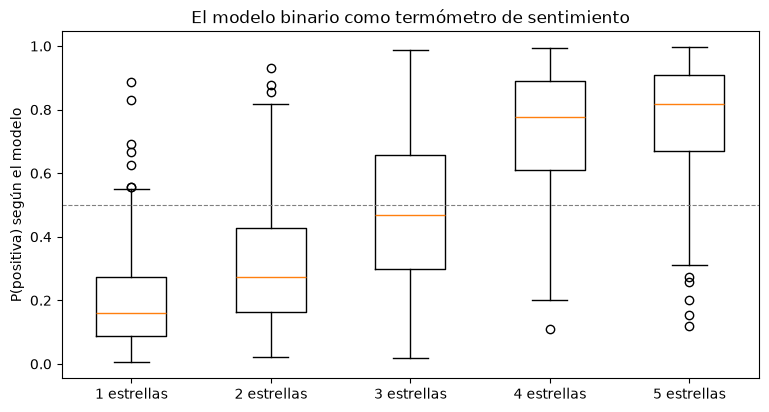

In [25]:
# Visualización (ya resuelta): distribución de P(positiva) según las estrellas
plt.figure(figsize=(9, 4.5))
plt.boxplot(list(prob_por_estrellas.values()), tick_labels=[f"{e} estrellas" for e in prob_por_estrellas])
plt.axhline(0.5, color="gray", ls="--", lw=0.8)
plt.ylabel("P(positiva) según el modelo")
plt.title("El modelo binario como termómetro de sentimiento")
plt.show()

**Para analizar**

1. ¿La probabilidad media crece con las estrellas? ¿Dónde quedan las de 3 estrellas, aunque el modelo nunca las vio?
2. ¿El modelo distingue mejor entre 1 y 2 estrellas o entre 4 y 5? ¿Por qué podría pasar?
3. Si tuvieras que clasificar reseñas en tres clases (negativa, neutral, positiva) usando solo este modelo, ¿cómo lo harías?

**Respuesta:** 1. Sí, crece de forma ordenada de 1 a 5 estrellas, y las de 3 quedan **en el medio** (cerca de 0.5), con una dispersión muy grande. El modelo nunca vio una reseña neutral, pero como mezclan palabras positivas y negativas, su probabilidad cae naturalmente en la zona intermedia. La probabilidad funciona como una medida continua de sentimiento.
2. Distingue mejor entre 1 y 2 estrellas (medias de 0.19 y 0.31) que entre 4 y 5 (0.74 y 0.77), aunque en el entrenamiento cada par tenía la misma etiqueta. Las reseñas de 2 estrellas suelen reconocer algo bueno ("está bien, pero...") y por eso suben hacia el centro. En cambio, las de 4 y 5 usan casi el mismo vocabulario positivo: la diferencia entre "muy bueno" y "excelente" es sutil incluso para una persona.
3. Con dos umbrales: por ejemplo, negativa si P < 0.3, positiva si P > 0.7 y neutral en medio. Habría que elegir los umbrales con datos de validación. La alternativa más directa es entrenar un modelo con las tres clases (o con las cinco estrellas, como en el reto del ejercicio 15).

---
# Parte 2. Similitud y redes neuronales

## Ejercicio 11. Un buscador de reseñas parecidas (similitud coseno)

En el tutorial usamos la similitud coseno para comparar embeddings de palabras. Ahora la usaremos para comparar **reseñas completas**, representadas con TF-IDF. Así funciona la búsqueda en muchas tiendas en línea: "otros clientes dijeron algo parecido".

a) Crea `vectorizador_busqueda`: un `TfidfVectorizer(strip_accents="unicode", stop_words=STOP_SIN_NEGACIONES)` y `matriz_resenas`: el resultado de aplicar `fit_transform` a **todas** las reseñas de `df["resena"]`.

b) Programa `buscar_parecidas(consulta, n=3)`: transforma la consulta con el vectorizador, calcula la similitud coseno con todas las reseñas (pista: `cosine_similarity(vector_consulta, matriz_resenas)[0]`) y devuelve un DataFrame con las `n` reseñas más parecidas y las columnas `similitud`, `estrellas` y `resena`.

**Solución**

In [26]:
vectorizador_busqueda = TfidfVectorizer(strip_accents="unicode", stop_words=STOP_SIN_NEGACIONES)
matriz_resenas = vectorizador_busqueda.fit_transform(df["resena"])


def buscar_parecidas(consulta, n=3):
    vector_consulta = vectorizador_busqueda.transform([consulta])
    similitudes = cosine_similarity(vector_consulta, matriz_resenas)[0]
    mejores = np.argsort(similitudes)[::-1][:n]
    return pd.DataFrame({"similitud": similitudes[mejores].round(3),
                         "estrellas": df["estrellas"].values[mejores],
                         "resena": df["resena"].values[mejores]})


for consulta in ["la batería dura muy poco", "la talla es más pequeña de lo normal", "llegó roto"]:
    print(f"Consulta: {consulta}")
    display(buscar_parecidas(consulta))

Consulta: la batería dura muy poco


,similitud,estrellas,resena
0,0.638,1,"Poca batería. Los tuve que devolver, la batería apenas dura una hora."
1,0.609,2,"bateria. es igual que la otra, y parece que viene mala, no carga nada y no dura la bateria nada"
2,0.603,2,"La bateria no dura nada. La bateria no dura ni doce horas, lo voy a probar un poco mas pero seguramente lo devolvere"


Consulta: la talla es más pequeña de lo normal


,similitud,estrellas,resena
0,0.772,3,Talla pequeña. Buen producto pero talla pequeña
1,0.575,3,"Talla pequeña. No cubre la cara,talla pequeña.En general el efecto de hidratación esta bien"
2,0.534,2,"Pequeña. pequeña me quedo, y pedí mi talla que es un 36"


Consulta: llegó roto


,similitud,estrellas,resena
0,0.797,3,Roto.. El protector de pantalla llegó un poco roto.
1,0.755,1,"Llegó roto. Llegó roto, imagino que en parte por correos."
2,0.727,1,Roto. Malísimo porque llegó el cierre roto


c) Ahora prueba dos consultas que significan **lo mismo** con palabras distintas. Guarda en `similitud_entre_consultas` la similitud coseno entre los vectores TF-IDF de ambas frases.

**Solución**

In [27]:
consulta_1 = "el envío fue lentísimo"
consulta_2 = "tardó muchísimo en llegar"

similitud_entre_consultas = cosine_similarity(vectorizador_busqueda.transform([consulta_1]),
                                              vectorizador_busqueda.transform([consulta_2]))[0, 0]
print(f"Similitud entre las dos consultas: {similitud_entre_consultas}")
display(buscar_parecidas(consulta_1))
display(buscar_parecidas(consulta_2))

Similitud entre las dos consultas: 0.0


,similitud,estrellas,resena
0,0.360,2,Muy lento. Es cómodo cargar de esta manera pero es lentisimo!! Un iPhone 8 Plus que necesite casi 4 horas me parece excesivo.
1,0.270,2,"Lento lentisimo. El termometro tarda un siglo en dar la temperatura, de 8 s nada. Es fiable, eso sí, pero has de conseguir que la criatura se esté..."
2,0.241,2,"Buen producto, mal servicio de envío.. La calidad buena, pero después de pagar más por el producto y gastos de envío a parte, no llegaron en fecha..."


,similitud,estrellas,resena
0,0.611,5,Tardo en llegar. Me tardo en llegar bastante. Pero duran después de haberlas comprado hace tiempo
1,0.560,3,Está bien. Cumple con su función. Pero me tardó mucho más en llegar de lo que ponía
2,0.451,4,Buena compra económica. Le doy 4 estrellas porque me tardó muchísimo en llegar pero es un buen usb cumple con sus perspectivas y para lo pequeño q...


**Para analizar:** ¿los resultados de las primeras consultas son relevantes? ¿Por qué la similitud entre "el envío fue lentísimo" y "tardó muchísimo en llegar" es 0? ¿Qué representación de texto resolvería este problema?

**Respuesta:** Para las tres primeras consultas los resultados son muy relevantes: comparten palabras poco frecuentes ("batería", "talla", "roto") que tienen un IDF alto. Pero TF-IDF solo compara **palabras idénticas**: las dos frases del punto c) no comparten ni un término, así que sus vectores son perpendiculares y la similitud es 0, aunque signifiquen lo mismo. Se nota también en los resultados: "el envío fue lentísimo" devuelve reseñas sobre un cargador y un termómetro "lentísimos" (coincide la palabra, no el sentido), mientras que "tardó muchísimo en llegar" sí encuentra quejas sobre el envío. Es el problema de los vectores dispersos (diapositiva 28). Lo resuelven los **embeddings**: vectores densos donde las palabras y frases con significado parecido quedan cerca, aunque se escriban distinto. Un buscador moderno usa embeddings de frases generados por un Transformer preentrenado.

## Ejercicio 12. Una red neuronal para el sentimiento

Entrenamos la misma arquitectura del tutorial:

```
reseña → tokens → ids → [Embedding] → promedio de los vectores → [Linear] → puntuación → sigmoide → P(positiva)
```

a) Construye el diccionario `vocab` con las palabras que aparecen **al menos 2 veces** en `X_train` (usa tu función `tokenizar()` del ejercicio 3). Reserva el id 0 para `"<pad>"` (relleno) y el 1 para `"<desconocida>"`.

b) Programa `codificar(texto)`: convierte el texto en una lista de exactamente `LARGO = 60` ids. Las palabras que no estén en `vocab` reciben el id 1; si hay más de 60 tokens se recorta, y si hay menos se rellena con 0.

Pista: es igual al ejercicio 16 del tutorial, pero con otra función de tokenización y otro largo.

**Solución**

In [28]:
contador_train = Counter(t for r in X_train for t in tokenizar(r))
vocab = {"<pad>": 0, "<desconocida>": 1}
for palabra, conteo in contador_train.items():
    if conteo >= 2:
        vocab[palabra] = len(vocab)

LARGO = 60


def codificar(texto):
    ids = [vocab.get(t, 1) for t in tokenizar(texto)][:LARGO]
    return ids + [0] * (LARGO - len(ids))


X_train_ids = torch.tensor([codificar(r) for r in X_train])
X_test_ids = torch.tensor([codificar(r) for r in X_test])
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

print(f"Vocabulario: {len(vocab)} palabras")
print("Reseña:", X_train.iloc[0])
print("Ids:   ", X_train_ids[0].tolist())

Vocabulario: 6513 palabras
Reseña: Spray. El envío. 6 días ha tardado en llegar. Y es que lo necesitaba cuanto antes...
Ids:    [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Celda ya resuelta: el modelo, la pérdida, el optimizador y el cargador de datos.

In [33]:
class ClasificadorSentimiento(nn.Module):
    def __init__(self, n_vocab, dim=32):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab, dim, padding_idx=0)   # un vector por palabra
        self.salida = nn.Linear(dim, 1)                              # una neurona final

    def forward(self, x):
        vectores = self.embedding(x)                                 # [batch, 60, 32]
        mascara = (x != 0).unsqueeze(-1).float()                     # ignoramos el relleno (id 0)
        promedio = (vectores * mascara).sum(dim=1) / mascara.sum(dim=1).clamp(min=1)
        return self.salida(promedio).squeeze(-1)                     # puntuación (logit)


torch.manual_seed(SEED)
red = ClasificadorSentimiento(len(vocab))
criterio = nn.BCEWithLogitsLoss()
optimizador = torch.optim.Adam(red.parameters(), lr=1e-2)
cargador = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train_ids, y_train_t),
                                       batch_size=64, shuffle=True)
print(red)
print(f"Parámetros: {sum(p.numel() for p in red.parameters()):,}")

ClasificadorSentimiento(
  (embedding): Embedding(6513, 32, padding_idx=0)
  (salida): Linear(in_features=32, out_features=1, bias=True)
)
Parámetros: 208,449


c) Escribe el **bucle de entrenamiento** de `EPOCAS = 8` épocas con los 4 pasos (predecir, medir el error, `backward`, `step`), sin olvidar `optimizador.zero_grad()`. Imprime la pérdida media de cada época y mide el tiempo total en `tiempo_red`.

d) Evalúa en el set de prueba: calcula `prob_red` (la probabilidad de ser positiva de cada reseña, como arreglo de NumPy) y `pred_red` (1 si `prob_red > 0.5`, 0 en caso contrario). Recuerda `red.eval()` y `torch.no_grad()`.

**Solución**

In [34]:
EPOCAS = 30
inicio = time.time()

for epoca in range(1, EPOCAS + 1):
    red.train()
    perdida_total = 0.0
    for x_lote, y_lote in cargador:
        optimizador.zero_grad()
        puntuaciones = red(x_lote)                  # 1. predecir
        perdida = criterio(puntuaciones, y_lote)    # 2. medir el error
        perdida.backward()                          # 3. repartir la culpa
        optimizador.step()                          # 4. ajustar

        perdida_total += perdida.item() * len(y_lote)
    print(f"Época {epoca} | pérdida: {perdida_total / len(y_train_t):.4f}")

tiempo_red = time.time() - inicio

red.eval()
with torch.no_grad():
    prob_red = torch.sigmoid(red(X_test_ids)).numpy()
pred_red = (prob_red > 0.5).astype(int)

print(f"Exactitud: {accuracy_score(y_test, pred_red):.3f} | F1: {f1_score(y_test, pred_red):.3f}")

Época 1 | pérdida: 0.4843
Época 2 | pérdida: 0.2609
Época 3 | pérdida: 0.1768
Época 4 | pérdida: 0.1257
Época 5 | pérdida: 0.0898
Época 6 | pérdida: 0.0642
Época 7 | pérdida: 0.0454
Época 8 | pérdida: 0.0331
Época 9 | pérdida: 0.0241
Época 10 | pérdida: 0.0181
Época 11 | pérdida: 0.0141
Época 12 | pérdida: 0.0110
Época 13 | pérdida: 0.0093
Época 14 | pérdida: 0.0078
Época 15 | pérdida: 0.0067
Época 16 | pérdida: 0.0058
Época 17 | pérdida: 0.0047
Época 18 | pérdida: 0.0044
Época 19 | pérdida: 0.0035
Época 20 | pérdida: 0.0028
Época 21 | pérdida: 0.0026
Época 22 | pérdida: 0.0021
Época 23 | pérdida: 0.0018
Época 24 | pérdida: 0.0015
Época 25 | pérdida: 0.0014
Época 26 | pérdida: 0.0012
Época 27 | pérdida: 0.0010
Época 28 | pérdida: 0.0010
Época 29 | pérdida: 0.0008
Época 30 | pérdida: 0.0008
Exactitud: 0.858 | F1: 0.859


**Para analizar:** la pérdida baja en cada época. ¿Significa eso que el modelo siempre mejora en el set de prueba? ¿Qué pasaría si entrenáramos 50 épocas?

**Respuesta:** No necesariamente. La pérdida que imprimimos es la de **entrenamiento**: mide qué tan bien el modelo se ajusta a las reseñas que ya vio. Con ~6,400 reseñas y más de 200 mil parámetros (casi todos en la tabla de embeddings), la red puede llegar a memorizarlas. Si entrenáramos 50 épocas, la pérdida de entrenamiento se acercaría a 0, pero la exactitud en prueba se estancaría o empeoraría: **sobreajuste**. Para elegir el número de épocas se usa un set de **validación** (separado de la prueba) y se detiene el entrenamiento cuando su métrica deja de mejorar (*early stopping*).

## Ejercicio 13. Los embeddings que aprendió la red

La capa `nn.Embedding` aprendió un vector de 32 números para cada palabra del vocabulario. Veamos qué palabras quedaron cerca.

a) Extrae la matriz de embeddings como arreglo de NumPy: `matriz_emb = red.embedding.weight.detach().numpy()`, y crea `id_a_palabra`, la lista de palabras ordenadas por su id (la inversa de `vocab`).

b) Programa `vecinas(palabra, n=8)`: devuelve las `n` palabras con **mayor similitud coseno** con `palabra` (sin incluirla), usando `cosine_similarity` o tu propia función.

**Solución**

In [35]:
matriz_emb = red.embedding.weight.detach().numpy()
id_a_palabra = sorted(vocab, key=vocab.get)


def vecinas(palabra, n=8):
    similitudes = cosine_similarity(matriz_emb[[vocab[palabra]]], matriz_emb)[0]
    orden = np.argsort(similitudes)[::-1]
    return [id_a_palabra[i] for i in orden if id_a_palabra[i] != palabra][:n]


for palabra in ["excelente", "horrible", "devolver", "talla", "rapido"]:
    print(f"{palabra:<10} → {vecinas(palabra)}")

excelente  → ['encantado', 'tenemos', 'perfeccion', 'paredes', 'encanto', 'cableado', 'sostiene', 'duda']
horrible   → ['lila', 'ocurrido', 'desear', 'sabria', 'compres', 'nuevas', 'suelta', 'huelen']
devolver   → ['defectuosa', 'evaluar', 'compres', 'normalita', 'solucionar', 'taller', 'desastre', 'ayer']
talla      → ['vivido', 'pestañitas', 'realidad', 'nuevas', 'gastarte', 'estomago', 'lavar', 'quemadura']
rapido     → ['pueden', 'intuitivo', 'logras', 'jugar', 'sentir', 'gama', 'colgando', 'diaria']


**Para analizar:** en el tutorial, los embeddings construidos con co-ocurrencias acercaban palabras del mismo **tema** ("dinner" y "lunch"). ¿Qué tienen en común las vecinas que encontraste aquí? ¿Por qué "talla" no tiene vecinas con sentido? ¿De qué depende lo que "significa" un embedding?

**Respuesta:** Aquí las vecinas que tienen sentido comparten la **polaridad**, no el tema: "excelente" queda cerca de "encantado", "encanto", "perfeccion" y "buen", y "devolver" cerca de "defectuosa", "mala" y "desastre", aunque hablen de cosas distintas. Mezcladas aparecen palabras sin relación ("paredes", "armarios", "lila"): son palabras raras, que la red vio pocas veces y que quedaron en posiciones casi aleatorias. "talla" y "rapido" aparecen tanto en reseñas buenas como malas, así que la red no necesitó darles una posición especial y sus vecinas no tienen sentido. Un embedding aprende lo que le sirve para **su tarea de entrenamiento**: esta red solo tenía que separar positivo de negativo, así que solo organizó el espacio en esa dirección. Los embeddings de Word2Vec o de un Transformer preentrenado se entrenan para predecir palabras en contexto con millones de textos, y por eso capturan significados mucho más ricos.

---
# Parte 3. Cierre

## Ejercicio 14. Comparación de modelos

Construye el DataFrame `comparacion` con una fila por modelo: **Naive Bayes**, **TF-IDF + Reg. logística** y **Red neuronal**, y las columnas `exactitud`, `precisión`, `recall`, `F1` y `tiempo (s)`. Reutiliza `resumen_metricas()` y las variables `tiempo_nb`, `tiempo_lr` y `tiempo_red`.

**Solución**

In [36]:
filas = {}
for nombre, pred, tiempo in [("Naive Bayes", pred_nb, tiempo_nb),
                             ("TF-IDF + Reg. logística", pred_lr, tiempo_lr),
                             ("Red neuronal", pred_red, tiempo_red)]:
    filas[nombre] = {**resumen_metricas(y_test, pred), "tiempo (s)": tiempo}

comparacion = pd.DataFrame(filas).T
comparacion.round(3)

,exactitud,precisión,recall,F1,tiempo (s)
Naive Bayes,0.879,0.859,0.906,0.882,0.100
TF-IDF + Reg. logística,0.902,0.905,0.898,0.901,0.237
Red neuronal,0.858,0.853,0.865,0.859,2.958


**Para analizar**

1. ¿Qué modelo elegirías para poner en producción? Justifica con métricas, tiempo e interpretabilidad.
2. Repasa los errores del ejercicio 9 (ironía, doble negación, "pero"). ¿Crees que la red neuronal de esta práctica los resuelve? ¿Qué tipo de modelo sí podría?

**Respuesta:** 1. Los tres quedan muy cerca (diferencias de 1 a 2 puntos de F1). La regresión logística con TF-IDF es una excelente elección: su F1 está entre los mejores, se entrena en menos de un segundo sin GPU y es **interpretable** (ejercicio 8: podemos explicar qué términos influyeron en cada decisión). La red neuronal tarda más y no la supera con claridad, que es justo el criterio de la diapositiva 52: si el modelo neuronal no supera claramente a la línea base clásica, no compensa.
2. No: nuestra red **promedia** los embeddings de las palabras, así que también pierde el orden; "no está nada mal" sigue siendo un promedio de "no", "nada" y "mal". Para resolver negaciones, contrastes e ironía hace falta un modelo que lea la secuencia completa y relacione las palabras entre sí: una LSTM o, mejor, un **Transformer preentrenado** (por ejemplo, BETO o un modelo multilingüe ajustado para sentimiento), cuya atención conecta "no" con "mal" y "pero" con lo que viene después.

## Ejercicio 15. Reto: predecir las 5 estrellas

Hasta ahora simplificamos el problema a dos clases. El reto es predecir directamente **el número de estrellas** (de 1 a 5), usando todas las reseñas de `df`, incluidas las de 3 estrellas.

a) Separa `df` en `train5` y `test5` (80/20), estratificando por `estrellas` y con `random_state=SEED`.

b) Entrena `modelo_5`: el pipeline `TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2), min_df=2, sublinear_tf=True)` + `LogisticRegression(max_iter=1000)`. La regresión logística de scikit-learn maneja varias clases automáticamente. Guarda las predicciones sobre `test5` en `pred_5`.

c) Calcula:
- `exactitud_5`: la exactitud exacta (acertar el número de estrellas).
- `exactitud_1`: el porcentaje de predicciones que se equivocan **como mucho en 1 estrella** (pista: `np.abs(pred - real) <= 1`).
- `error_medio`: el error absoluto medio en estrellas.

**Solución**

In [37]:
train5, test5 = train_test_split(df, test_size=0.2, stratify=df["estrellas"], random_state=SEED)

modelo_5 = make_pipeline(TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                         LogisticRegression(max_iter=1000))
modelo_5.fit(train5["resena"], train5["estrellas"])
pred_5 = modelo_5.predict(test5["resena"])

diferencia = np.abs(pred_5 - test5["estrellas"].values)
exactitud_5 = accuracy_score(test5["estrellas"], pred_5)
exactitud_1 = np.mean(diferencia <= 1)
error_medio = diferencia.mean()

print(f"Exactitud exacta: {exactitud_5:.3f} | a 1 estrella como mucho: {exactitud_1:.3f} | "
      f"error medio: {error_medio:.2f} estrellas")

Exactitud exacta: 0.506 | a 1 estrella como mucho: 0.885 | error medio: 0.64 estrellas


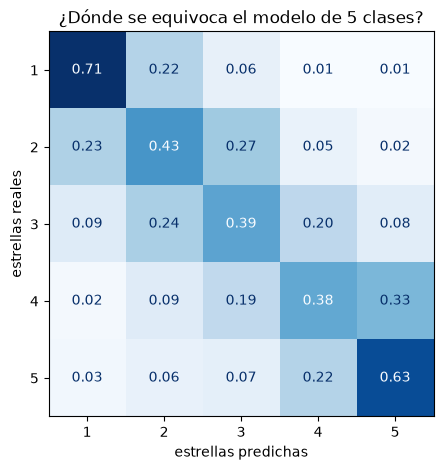

In [38]:
# Visualización (ya resuelta): matriz de confusión de las 5 estrellas, normalizada por fila
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(test5["estrellas"], pred_5, normalize="true", values_format=".2f",
                                        cmap="Blues", ax=ax, colorbar=False)
ax.set_xlabel("estrellas predichas")
ax.set_ylabel("estrellas reales")
ax.set_title("¿Dónde se equivoca el modelo de 5 clases?")
plt.show()

**Para analizar**

1. La exactitud exacta parece baja. ¿Qué exactitud tendría un modelo que adivina al azar entre 5 clases balanceadas? ¿Y qué dice `exactitud_1`?
2. En la matriz de confusión, ¿dónde se concentran los errores? ¿Qué clase es la más difícil?
3. Este modelo trata las estrellas como **categorías sin orden**: para él, confundir 1 con 2 es tan grave como confundir 1 con 5. ¿Cómo podrías aprovechar que las estrellas están ordenadas?

**Respuesta:** 1. Al azar acertaríamos un 20%; el modelo acierta más del doble. Además, la gran mayoría de sus predicciones (alrededor de 9 de cada 10) se equivocan como mucho en una estrella: casi siempre identifica bien la "zona" de la reseña.
2. Los errores se concentran **junto a la diagonal**: 1 se confunde con 2, 4 con 5, y así. Confundir 1 con 5 casi nunca pasa (2% o menos). Las clases extremas son las más fáciles (acierta el 71% de las de 1 estrella y el 63% de las de 5), y las intermedias, las más difíciles: las de 4 estrellas solo se aciertan un 38% de las veces (un tercio se confunde con 5) y las de 3, un 39%. Comparten vocabulario con las vecinas por ambos lados; ni siquiera una persona distingue bien un 4 de un 5 leyendo solo el texto.
3. Tratándolo como un problema de **regresión** (predecir un número, por ejemplo con `Ridge`, y redondear) o de **regresión ordinal**. Otra opción simple: usar las probabilidades de las 5 clases y predecir la **estrella esperada** (Σ estrellas × probabilidad), que penaliza menos los errores pequeños. Y para evaluar, el error medio en estrellas es más justo que la exactitud exacta.